Quais comportamentos e características aumentam significativamente a probabilidade de churn?    
É possível identificar sinais comportamentais precoces de churn com antecedência suficiente para ações de retenção?   
Qual modelo melhor separa clientes de alto e baixo risco de churn com equilíbrio entre precisão e capacidade operacional?   
Como priorizar clientes por risco de churn e valor financeiro?  
Qual métrica melhor representa a capacidade do modelo em identificar churn acionável sem gerar excesso de falso positivo?  
Como traduzir previsões de churn em impacto financeiro, priorização operacional e ações de retenção?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(r"C:\Users\rafae\OneDrive\Documentos\Projetos_Data_Science\Customer_Health_Score\WA_Fn-UseC_-Telco-Customer-Churn.csv")

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

#Não há nenhum valor nulo, porém a coluna "TotalCharges" está como string, sendo que deveria ser numérico.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [5]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
#Preenchimento onde os valores de TotalCharges são nulos pela mediana
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.shape

(7043, 21)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Churn"].value_counts(normalize=True)

#Nesse dataset, 73% dos clientes não tiveram Churn, ou seja, aproximadamente 1/4 dos clientes deu churn, o que é consideravelmente alto para um serviço

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

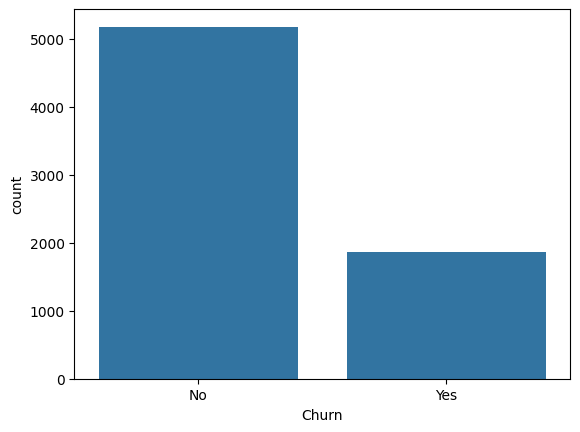

In [12]:
sns.countplot(data=df, x="Churn")

<Axes: xlabel='Churn', ylabel='tenure'>

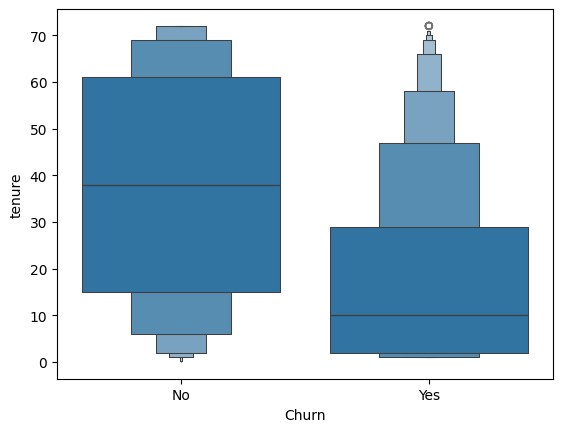

In [13]:
sns.boxenplot(data = df, x="Churn", y="tenure")

#tenure é o tempo de relacionamento em meses que um cliente tem com a empresa.
#para essa analise, temos que a concentraçao de clientes que deram Churn possuem tempo de relacionamento menor que 30 meses. 
#Para cliente que não deram Churn, a faixa está entre 15 e 60 meses.


In [14]:
df.groupby("Churn")["tenure"].quantile([0.25, 0.50, 0.75, 1])

Churn      
No     0.25    15.0
       0.50    38.0
       0.75    61.0
       1.00    72.0
Yes    0.25     2.0
       0.50    10.0
       0.75    29.0
       1.00    72.0
Name: tenure, dtype: float64

<Axes: xlabel='Contract', ylabel='count'>

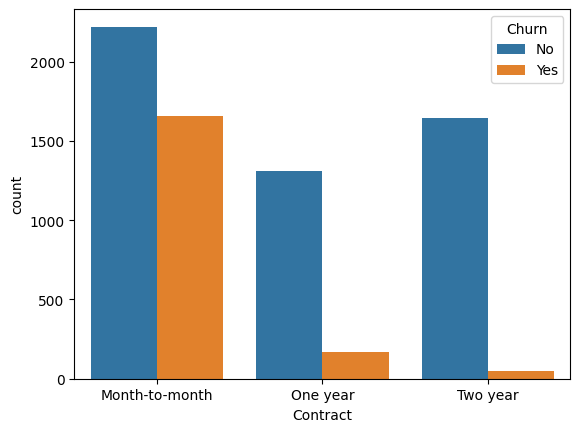

In [15]:
sns.countplot(data=df, x="Contract", hue="Churn")
#A probabilidade de reter clientes com contratos longos é maior, visto que os contratos mensais estão praticamente 60/40 entre Churn e "não Churn".
#Uma das ações a serem feitas é tentar fidelizar os cliente para adquirirem contratos mais longos, evitando possiveis Churns futuros

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

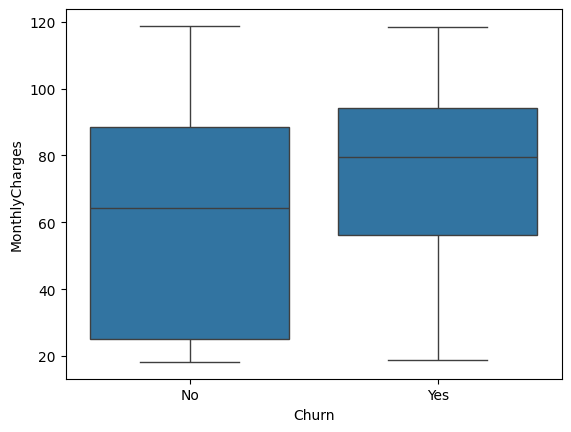

In [16]:
sns.boxplot(data= df, x = "Churn", y= "MonthlyCharges" )

#Para esse grafico, 

In [17]:
pd.crosstab(df["Contract"],df["Churn"], normalize= 'index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [19]:
df['Churn_bin'] = (df["Churn"]=='Yes').astype(int)
print(df['Churn_bin'])

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_bin, Length: 7043, dtype: int64


In [30]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_bin
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


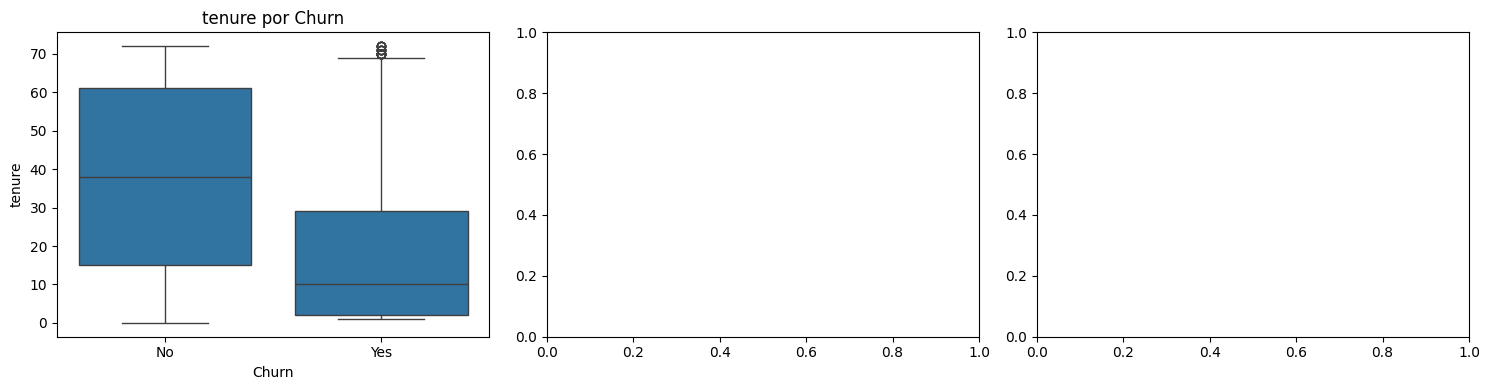

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [31]:
num = ['tenure', 'MonthlyCharges', 'TotalCharges']
fix, axes = plt.subplots(1, 3, figsize = (15, 4))

for i, col in enumerate(num):
    df[col] = pd.to_numeric(df[col], errors= 'coerce')
    sns.boxplot(data=df, x = 'Churn', y = col, ax = axes[i])
    axes[i].set_title(f'{col} por Churn')
    
    plt.tight_layout()
    plt.show()

In [32]:
categoricas = ['Contract', 'PaymentMethod',
               'InternetService', 'TechSupport']

churn_rates = {}
for col in categoricas:
    rate = df.groupby(col)['Churn_bin'].mean()
    churn_rates[col] = rate
    print(f"\n{col}:")
    print(rate.sort_values(ascending=False).round(3))


Contract:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn_bin, dtype: float64

PaymentMethod:
PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn_bin, dtype: float64

InternetService:
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn_bin, dtype: float64

TechSupport:
TechSupport
No                     0.416
Yes                    0.152
No internet service    0.074
Name: Churn_bin, dtype: float64
